In [1]:
from pathlib import Path

from PIL import Image

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True)
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()

  return df

In [16]:
data_dir = Path('../blockies_datasets/simple/mutation_only')
dataset = 'xai'

df = load_dataframe(data_dir, dataset)

In [17]:
(df.ill == 0).sum()

np.int64(3)

In [18]:
df.sample(5)

,obj_name,num_ill_chars,ill_chars,labeling_error,main_spherical,sec_spherical,num_sec_bones,bending,obj_rotation_roll,obj_rotation_pitch,...,resolution,id,original_id,_attributes_status,label,__module__,__name__,filename,ill,sphere_diff
5,ocd,1,[mutation_mainbones],False,1.158860,1.036458,1,0.032718,-0.002991,-0.200105,...,"[256, 256]",5d25dbcf-f6ac-45c5-bc85-9631c218038d,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,5d25dbcf-f6ac-45c5-bc85-9631c218038d.png,1,0.122402
6,healthy,0,[],False,0.027387,0.323050,3,0.062830,0.030692,0.099804,...,"[256, 256]",e5f738f7-2af8-462c-af86-68ef294a1797,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,e5f738f7-2af8-462c-af86-68ef294a1797.png,0,0.295664
1,ocd,1,[mutation_mainbones],False,1.117277,0.950843,2,0.147998,0.002554,-0.253401,...,"[256, 256]",2d452c81-7540-4979-8e77-8c71ee9b5c19,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,2d452c81-7540-4979-8e77-8c71ee9b5c19.png,1,0.166434
7,ocd,1,[mutation_mainbones],False,1.169641,1.008715,2,0.110593,-0.017988,-0.112817,...,"[256, 256]",711e0b08-96e2-48ba-8149-ef51eb989834,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,711e0b08-96e2-48ba-8149-ef51eb989834.png,1,0.160925
4,ocd,1,[mutation_mainbones],False,1.168868,1.008037,1,0.067976,0.034095,-0.066383,...,"[256, 256]",1acd88c2-d0d8-4f39-98ce-54cf4dd62c04,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",ocd,blockies.scene_parameters,SceneParameters,1acd88c2-d0d8-4f39-98ce-54cf4dd62c04.png,1,0.160831


In [19]:
df.columns

Index(['obj_name', 'num_ill_chars', 'ill_chars', 'labeling_error',
       'main_spherical', 'sec_spherical', 'num_sec_bones', 'bending',
       'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw', 'fliplr',
       'position_x', 'position_y', 'arm_position', 'obj_color',
       'obj_color_rgba', 'bg_color', 'bg_color_rgba', 'resolution', 'id',
       'original_id', '_attributes_status', 'label', '__module__', '__name__',
       'filename', 'ill', 'sphere_diff'],
      dtype='object')

<Axes: xlabel='bending', ylabel='Count'>

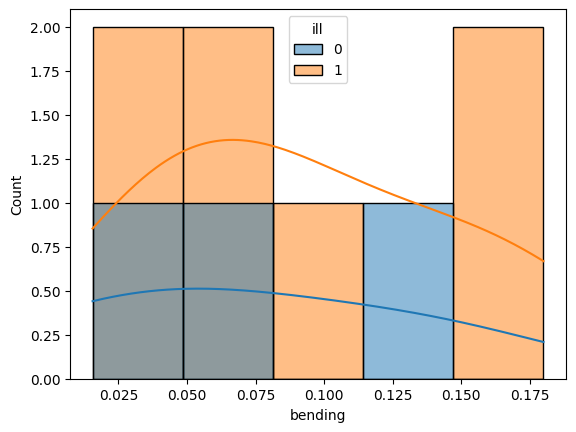

In [20]:
sns.histplot(data=df, x='bending', hue='ill', kde=True)

<Axes: xlabel='main_spherical', ylabel='Count'>

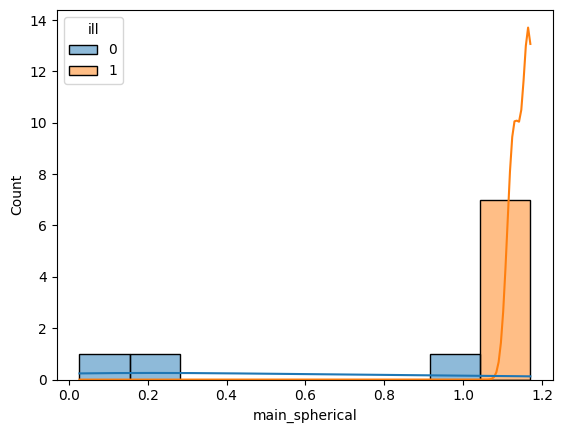

In [21]:
sns.histplot(data=df, x='main_spherical', hue='ill', kde=True)

<Axes: xlabel='sec_spherical', ylabel='Count'>

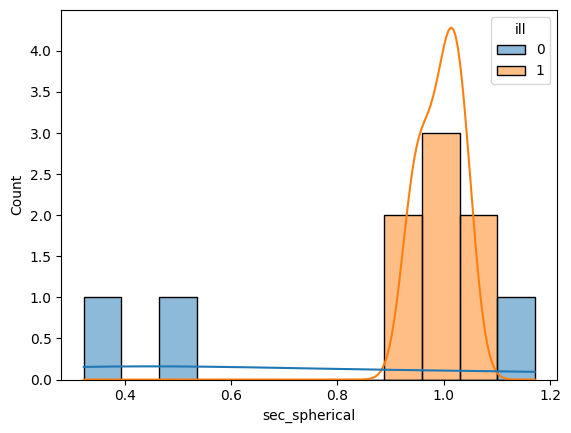

In [22]:
sns.histplot(data=df, x='sec_spherical', hue='ill', kde=True)

<Axes: xlabel='sphere_diff', ylabel='Count'>

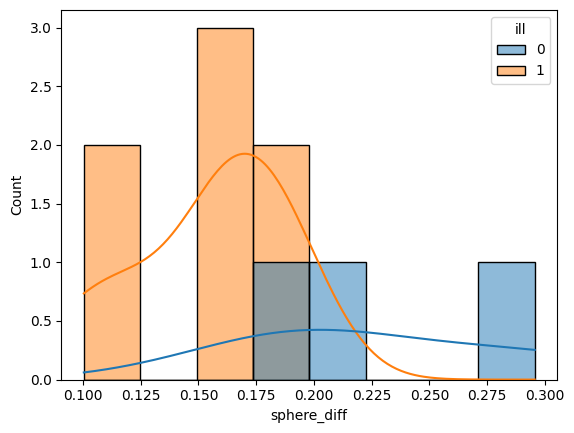

In [23]:
sns.histplot(data=df, x='sphere_diff', hue='ill', kde=True)

<Axes: xlabel='num_sec_bones', ylabel='Count'>

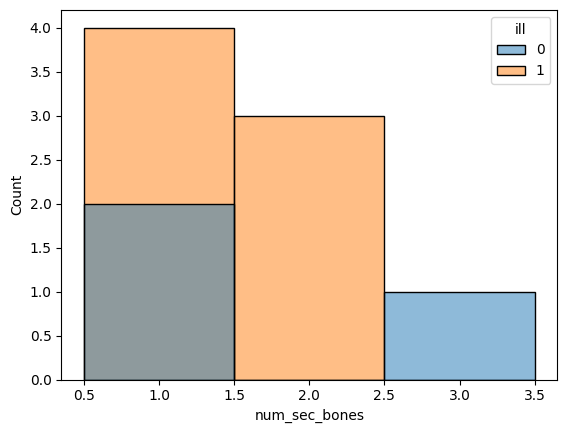

In [24]:
sns.histplot(data=df, x='num_sec_bones', hue='ill', kde=False, discrete=True)

<Axes: xlabel='arm_position', ylabel='Density'>

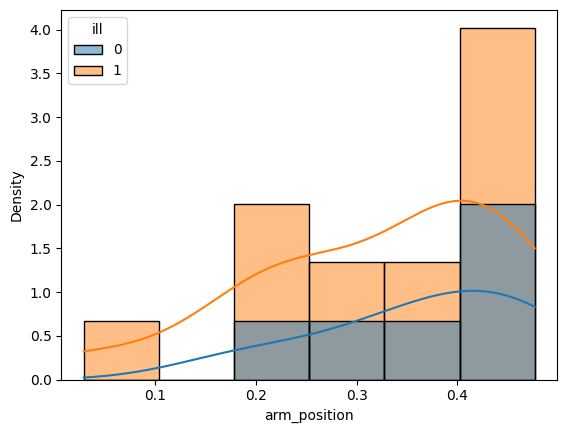

In [106]:
sns.histplot(data=df, x='arm_position', hue='ill', kde=True, stat='density')

In [102]:
def load_imgs(paths):
  imgs = []
  for path in paths:
      img = Image.open(path).convert('RGB')
      imgs.append(img)
  return imgs

In [103]:
notill_samples = df[df.ill == 0].sample(6)
paths = notill_samples.filename.apply(lambda x: data_dir / dataset / x)
notill_imgs = load_imgs(paths)
ill_samples = df[df.ill == 1].sample(6)
paths = ill_samples.filename.apply(lambda x: data_dir / dataset / x)
ill_imgs = load_imgs(paths)

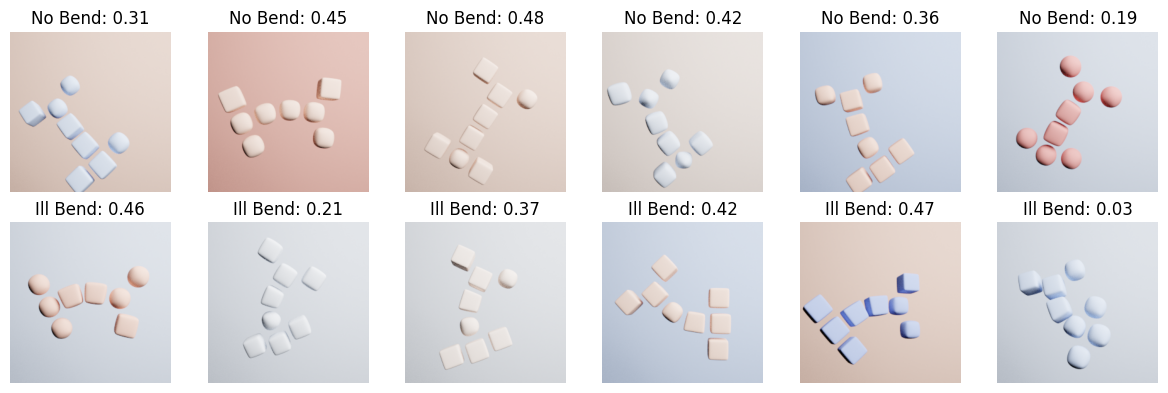

In [107]:
axes = plt.subplots(2, 6, figsize=(12, 4))[1]
for i, img in enumerate(notill_imgs):
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'No Bend: {notill_samples.iloc[i].arm_position:.2f}')
for i, img in enumerate(ill_imgs):
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Ill Bend: {ill_samples.iloc[i].arm_position:.2f}')
plt.tight_layout()
plt.show()